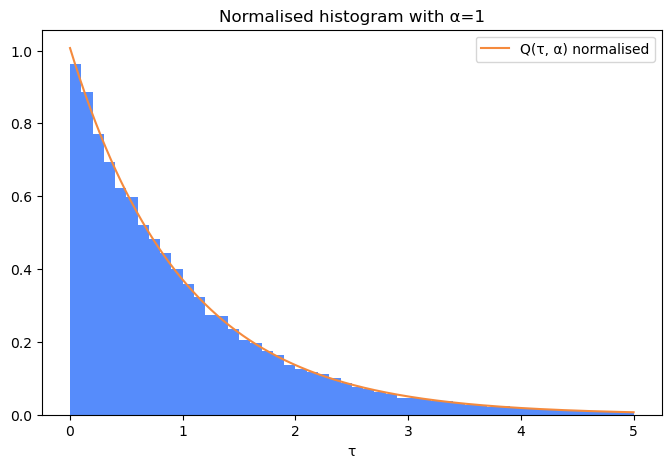

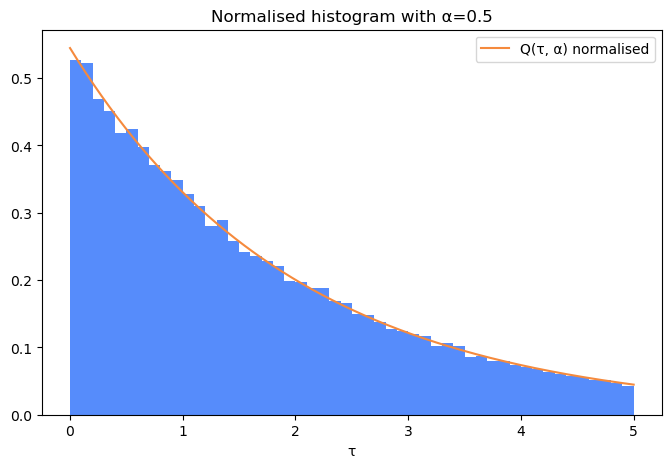

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def f_1(tau):
    normalisation = 1-np.exp(-5)
    return np.exp(-tau)/normalisation

def f_0_5(tau):
    normalisation = 2*(1-np.exp(-5/2))
    return np.exp(-0.5*tau)/normalisation

df = pd.read_csv("../data/task5/histogram.csv", dtype="double")
tau_values = np.linspace(0, 5, 1000)

histograms = [
    (1, f_1, "../report/figures/task5/histogram_alpha_1.pdf"),
    (0.5, f_0_5, "../report/figures/task5/histogram_alpha_0_5.pdf"),
]

for alpha, f, filename in histograms:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(df[df["alpha"] == alpha].tau, bins=50, density=True)
    ax.plot(tau_values, f(tau_values), label="Q(τ, α) normalised")

    ax.set_title(f"Normalised histogram with α={alpha}")
    ax.set_xlabel("τ")
    ax.legend()

    fig.savefig(filename)


In [7]:
df = pd.read_csv("../data/task5/histogram.csv", dtype="double")


I1_exact = 1. - 6. * np.exp(-5)
I2_exact = 2. - 37. * np.exp(-5)

I3_exact = 2.850810019265417
I4_exact = 7.298990145866727

Z_1 = 1-np.exp(-5)
Z_2 = 2*(1-np.exp(-5/2))

a_1_count = len(df[df["alpha"] == 1])
a_0_5_count = len(df[df["alpha"] == 0.5])

print(f"alpha=1 count: {a_1_count}")
print(f"alpha=0.5 count: {a_0_5_count}")
print(f"ratio: {a_1_count/a_0_5_count}")

I1 = np.mean(df[df["alpha"]==1].tau)*Z_1
I2 = np.mean(df[df["alpha"]==1].tau**2)*Z_1

I3 = np.mean(df[df["alpha"]==0.5].tau)*Z_2
I4 = np.mean(df[df["alpha"]==0.5].tau**2)*Z_2

print(f"I1: {I1}, correct result: {I1_exact} with error: {np.abs(I1-I1_exact)}")
print(f"I2: {I2}, correct result: {I2_exact} with error: {np.abs(I2-I2_exact)}")
print(f"I3: {I3}, correct result: {I3_exact} with error: {np.abs(I3-I3_exact)}")
print(f"I4: {I4}, correct result: {I4_exact} with error: {np.abs(I4-I4_exact)}")

alpha=1 count: 351326
alpha=0.5 count: 648674
ratio: 0.5416064155492589
I1: 0.9539838125218674, correct result: 0.9595723180054871 with error: 0.005588505483619777
I2: 1.7241482341574572, correct result: 1.7506959610338377 with error: 0.026547726876380517
I3: 2.844219292943757, correct result: 2.850810019265417 with error: 0.006590726321659801
I4: 7.2540642788951235, correct result: 7.298990145866727 with error: 0.04492586697160306


## Task6

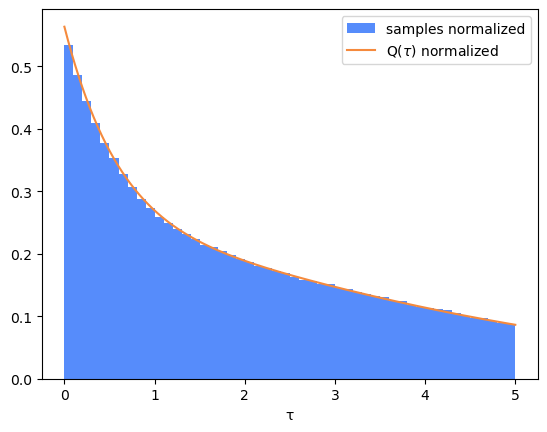

In [15]:
normalisation = 1 # didnt calculate yet
betas = [1/4, 3/4]

def f(tau, betas):
    my_sum = 0
    for beta in betas:
        my_sum+=1/(beta-1)*(tau+1/(beta-1)*(np.exp(-(beta-1)*tau)-1))

    return np.exp(-tau)*(1+0.25*my_sum)

df = pd.read_csv("../data/task6/histogram.csv")

plt.hist(df, bins=50, density=True, label="samples normalized")

tau_values = np.linspace(0, 5, 1000)
plt.plot(tau_values, f(tau_values, betas)*1/1.775, label="Q($\\tau$) normalized")
plt.xlabel("τ")
plt.legend()
plt.savefig("../report/figures/task6/histogram.pdf")
